# Performs N0 estimates and RDN0 subtraction for QE 

In [1]:
using CMBLensing, Statistics, PythonCall
using Plots
using LinearAlgebra
using Printf
using ProgressMeter


┌ Error: LLVM extensions library unavailable for your platform:
│   x86_64-apple-darwin-libgfortran5-cxx11-llvm_version+18-julia_version+1.12.6
│ LLVM.jl will not be functional.
│ 
│ If you are using a custom version of LLVM, try building a
│ custom version of LLVMExtra_jll using `deps/build_local.jl`
└ @ LLVM /Users/louis/.julia/packages/LLVM/bzSzE/src/LLVM.jl:103


In [2]:
# Setup simulation - use default parameters to avoid calling Python CAMB

Cℓ = camb()  # uses pre-computed default Cls
Cℓn = noiseCℓs(μKarcminT=1, ℓknee=1)
θpix = 3.0  # pixel size in arcmin
Nside = 512
T = Float32
beamFWHM = 0.  # beam FWHM in arcmin
lmax_ivf = 3000 # maximum multipole for band pas filtering 
pol = :I # I for temperature-only, or :P for polarization or :IP for both
which = :TT
ℓedges = 0:100:5000


sim0 = load_sim(
    ;
    seed = 0,
    Cℓ = Cℓ,
    Cℓn = Cℓn,
    θpix = θpix,
    T = T,
    Nside = Nside,
    pol = pol,
    beamFWHM = beamFWHM,  # beam FWHM in arcmin
    bandpass_mask = LowPass(lmax_ivf),
)

(f = ComplexF32[0.0f0 + 0.0f0im, -114292.17f0 + 4.0284998f6im, 139017.78f0 - 1.3339055f6im, 74564.8f0 - 631632.75f0im, -1.0328382f6 + 423086.28f0im, -425161.4f0 - 153093.5f0im, -341845.72f0 + 762393.5f0im, -1.3609758f6 + 48410.46f0im, 375312.25f0 + 71842.87f0im, -28113.95f0 + 252302.55f0im  …  -830.7366f0 - 565.1846f0im, 567.0215f0 + 901.7293f0im, 418.75845f0 - 719.0265f0im, -91.685265f0 + 219.27193f0im, -918.94806f0 - 946.1036f0im, 87.89339f0 - 557.738f0im, -47.827526f0 - 162.91974f0im, -224.3567f0 + 610.5367f0im, -308.1778f0 + 55.92609f0im, 350.3321f0 + 102.01224f0im], f̃ = Float32[-87.08865, -110.8872, -131.08359, -155.99986, -195.4116, -217.66446, -217.07281, -201.23303, -195.9404, -205.82736  …  32.088215, 37.723034, 68.60631, 67.60685, 28.739164, 28.992926, 40.05611, 25.744513, -4.1769285, -43.842262], ϕ = ComplexF32[0.0f0 + 0.0f0im, -0.5130842f0 - 0.5982984f0im, -0.22562023f0 + 0.68419427f0im, -0.19804808f0 - 0.16677861f0im, -0.037257683f0 + 0.12559262f0im, -0.10026877f0 + 0.071

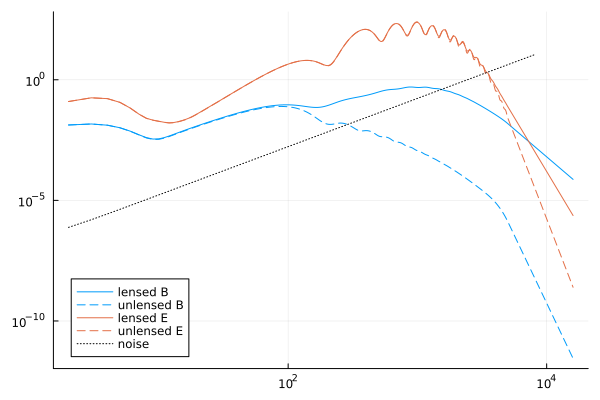

In [3]:
plot(ℓ² * Cℓ.total.BB, xscale=:log10, yscale=:log10, label="lensed B", color=1)
plot!(ℓ² * Cℓ.unlensed_total.BB, ls=:dash, label="unlensed B", color=1)
plot!(ℓ² * Cℓ.total.EE, label="lensed E", color=2)
plot!(ℓ² * Cℓ.unlensed_total.EE, ls=:dash, label="unlensed E", color=2)
plot!(ℓ² * Cℓn.BB, ls=:dot, color=:black, label="noise", legend=:bottomleft)
# legend(["lensed B","unlensed B","lensed E","unlensed E", "noise (beam not deconvolved)"]);


┌ Warning: Keyword argument hover not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotation, guidefo

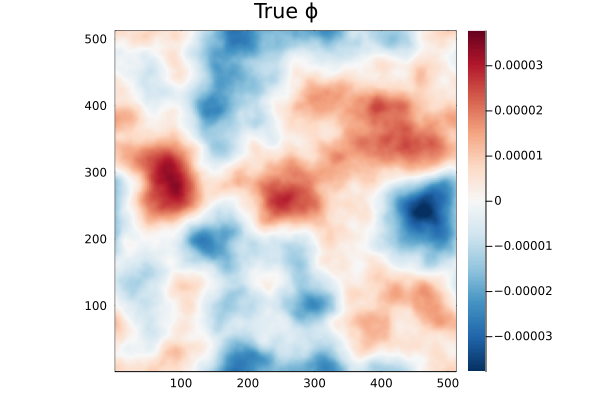

In [4]:
plot(sim0.ϕ, title="True ϕ", aspect_ratio=1)

In [5]:
println("Running quadratic estimate...")
(;ϕqe, AL, Nϕ) = quadratic_estimate(sim0.ds, which, wiener_filtered=false, weights=:unlensed)

# ϕqe = LowPass(2 * lmax_ivf - 2) * ϕqe
Cℓ_ϕqe = get_Cℓ(ϕqe; ℓedges)


Running quadratic estimate...


Cℓs{Vector{Float64}, Vector{Float64}}([75.5859784184188, 161.4816697488842, 257.08961557715776, 355.36867402589723, 454.5251933803815, 553.4419159538242, 652.8159299504382, 752.4372661461331, 851.6380381511643, 951.2924166060047  …  4049.3739175447404, 4149.269563616017, 4249.16265433738, 4349.120744273543, 4448.975833119803, 4548.496290293397, 4648.1816017529845, 4747.68133366465, 4845.955367017637, 4942.27394215414], [1.07883570135129e-13, 1.1928787958973139e-15, 1.5623272187099375e-16, 3.790842181461416e-17, 1.2308196919743125e-17, 5.6953309326165364e-18, 2.7522635377457167e-18, 1.5985083074576669e-18, 9.127454392099211e-19, 6.240613834813254e-19  …  1.3834599853987646e-20, 1.5998158738755618e-20, 1.739686227456972e-20, 1.9357228807348172e-20, 2.1797719949402164e-20, 2.3982101887264605e-20, 2.4616061861662586e-20, 2.6634420495159608e-20, 2.922883527818564e-20, 2.7273879296656646e-20], true, CMBLensing.var"#134#135"{Float64, Vector{Float64}, Vector{Float64}, Vector{Float64}}(NaN, [75

In [6]:
Cϕ_diag = diag(sim0.ds.Cϕ)
Nϕ_diag = diag(Nϕ)
WF = Diagonal(@.nan2zero(Cϕ_diag / (Cϕ_diag + Nϕ_diag)))
ϕqewf = WF * ϕqe

131584-element 512×512-pixel 3.0′-resolution LambertFourier{Array{ComplexF32, 2}}:
         -0.0f0 - 0.0f0im
   0.14361306f0 - 0.6642405f0im
  -0.41308442f0 + 0.46898034f0im
  -0.10965714f0 - 0.14594977f0im
   -0.1150145f0 + 0.09794593f0im
  -0.10389713f0 + 0.031017974f0im
 -0.043475807f0 - 0.038550694f0im
 -0.011674394f0 + 0.029034704f0im
  0.010350808f0 + 0.02410424f0im
 -0.007856107f0 + 0.012725255f0im
                ⋮
   2.6117947f-8 - 1.1529905f-7im
  -2.6908248f-8 + 1.096485f-7im
  -1.7324598f-7 + 5.537923f-8im
   -4.318843f-8 + 1.843418f-7im
    -8.11176f-8 - 6.9113835f-9im
  -5.4249213f-8 - 2.0532337f-8im
   2.7152183f-9 + 6.778581f-9im
   9.6936404f-8 + 1.6702884f-7im
   1.2153353f-7 + 1.16379875f-8im

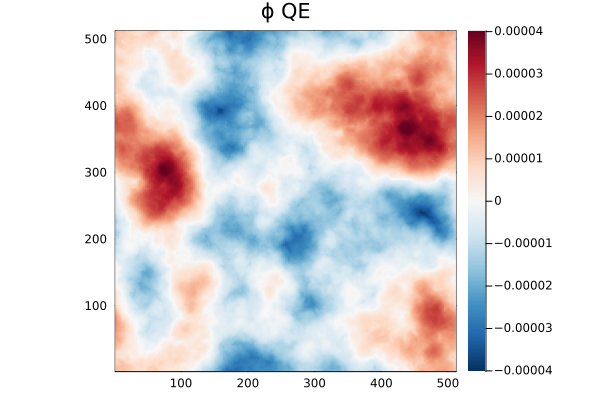

In [7]:
plot(ϕqe, title="ϕ QE", aspect_ratio=1)


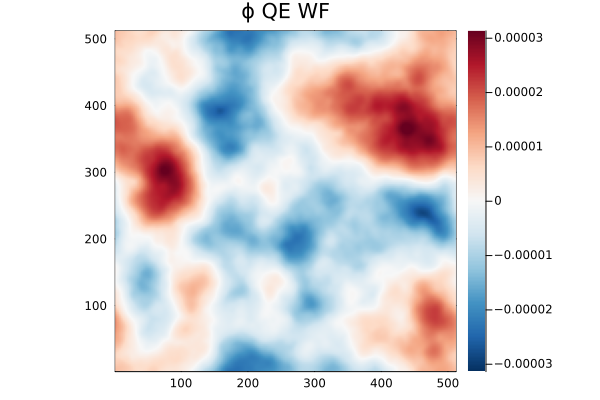

In [8]:
plot(ϕqewf, title="ϕ QE WF", aspect_ratio=1)

In [ ]:
Cl_cross = get_Cℓ(ϕqe, sim0.ϕ; ℓedges)  # cross-power between the QE and the true ϕ
Cℓ_N0 = cov_to_Cℓ(Nϕ; ℓedges) # N0 bias 


Cℓs{Vector{Float64}, Vector{Float64}}([75.5859784184188, 161.4816697488842, 257.08961557715776, 355.36867402589723, 454.5251933803815, 553.4419159538242, 652.8159299504382, 752.4372661461331, 851.6380381511643, 951.2924166060047  …  4049.3739175447404, 4149.269563616017, 4249.16265433738, 4349.120744273543, 4448.975833119803, 4548.496290293397, 4648.1816017529845, 4747.68133366465, 4845.955367017637, 4942.27394215414], [5.130458802756509e-14, 4.618068005256427e-16, 7.397206983490562e-17, 2.2826923018786562e-17, 8.646166339147167e-18, 4.0075341969797375e-18, 2.1827737978830393e-18, 1.2500441274120346e-18, 7.617231538660178e-19, 5.107891974879629e-19  …  1.316094844927596e-20, 1.4719074124811075e-20, 1.624736745466203e-20, 1.7951269744610394e-20, 2.044713399532509e-20, 2.2388251341597546e-20, 2.3564412820037855e-20, 2.5088168418748802e-20, 2.5956822697845305e-20, 2.6077649968290554e-20], true, CMBLensing.var"#134#135"{Float64, Vector{Float64}, Vector{Float64}, Vector{Float64}}(NaN, [75.5

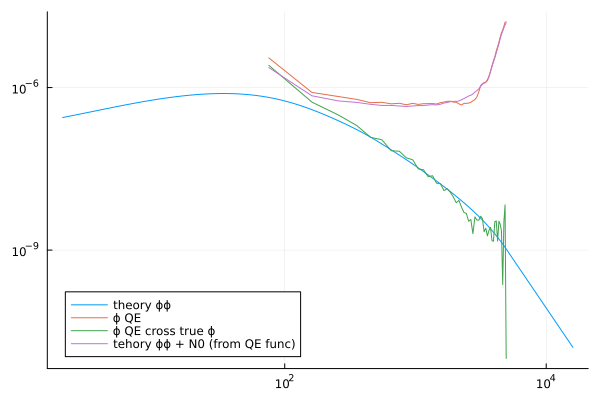

In [10]:
plot(ℓ⁴ * Cℓ.total.ϕϕ, xscale=:log10, yscale=:log10, label="theory ϕϕ")
plot!(Cℓ_ϕqe.ℓ,  max.(Cℓ_ϕqe.ℓ.^4 .*Cℓ_ϕqe.Cℓ, 1e-11), label="ϕ QE", legend=:bottomleft)
plot!(Cl_cross.ℓ,  max.(Cl_cross.ℓ.^4 .*Cl_cross.Cℓ, 1e-11), label="ϕ QE cross true ϕ")

plot!(ℓ⁴ * (Cℓ.total.ϕϕ + Cℓ_N0), label="tehory ϕϕ + N0 (from QE func)")



In [11]:
println("Computing standard N0...")
res_N0 = N0_bias(sim0.ds, which)
N0 = res_N0.N0
AL = res_N0.AL

CL_N0 = cov_to_Cℓ(N0; ℓedges)


Computing standard N0...


Cℓs{Vector{Float64}, Vector{Float64}}([75.5859784184188, 161.4816697488842, 257.08961557715776, 355.36867402589723, 454.5251933803815, 553.4419159538242, 652.8159299504382, 752.4372661461331, 851.6380381511643, 951.2924166060047  …  4049.3739175447404, 4149.269563616017, 4249.16265433738, 4349.120744273543, 4448.975833119803, 4548.496290293397, 4648.1816017529845, 4747.68133366465, 4845.955367017637, 4942.27394215414], [5.1304582931266267e-14, 4.618068005256427e-16, 7.397206983490562e-17, 2.2826923018786562e-17, 8.646166339147167e-18, 4.0075341969797375e-18, 2.1827737978830393e-18, 1.2500441274120346e-18, 7.617231538660178e-19, 5.107891974879629e-19  …  1.316094844927596e-20, 1.4719074124811075e-20, 1.624736745466203e-20, 1.7951269744610394e-20, 2.044713399532509e-20, 2.2388251341597546e-20, 2.3564409731616864e-20, 2.5088166425475226e-20, 2.5956822697845305e-20, 2.6077649968290554e-20], true, CMBLensing.var"#134#135"{Float64, Vector{Float64}, Vector{Float64}, Vector{Float64}}(NaN, [75.

In [12]:
println("Computing realization-dependent N0...")
res_RD = N0_bias(sim0.ds, which; realization_spec=:data)
N0_RD = res_RD.N0
CL_N0_RD = cov_to_Cℓ(N0_RD; ℓedges)

Computing realization-dependent N0...


Cℓs{Vector{Float64}, Vector{Float64}}([75.5859784184188, 161.4816697488842, 257.08961557715776, 355.36867402589723, 454.5251933803815, 553.4419159538242, 652.8159299504382, 752.4372661461331, 851.6380381511643, 951.2924166060047  …  4049.3739175447404, 4149.269563616017, 4249.16265433738, 4349.120744273543, 4448.975833119803, 4548.496290293397, 4648.1816017529845, 4747.68133366465, 4845.955367017637, 4942.27394215414], [5.2601341262666924e-14, 4.725127799233984e-16, 7.580600106813244e-17, 2.3480614023794708e-17, 8.89438979723602e-18, 4.1198768434240175e-18, 2.2415622679264677e-18, 1.28263030290134e-18, 7.817804847748819e-19, 5.211575860308713e-19  …  1.3343647319900947e-20, 1.4900318468818725e-20, 1.6506461518854842e-20, 1.8269239536980002e-20, 2.0894466932132408e-20, 2.2985855533746083e-20, 2.43755402673993e-20, 2.6121927933114502e-20, 2.694117868712493e-20, 2.691185652350534e-20], true, CMBLensing.var"#134#135"{Float64, Vector{Float64}, Vector{Float64}, Vector{Float64}}(NaN, [75.5859

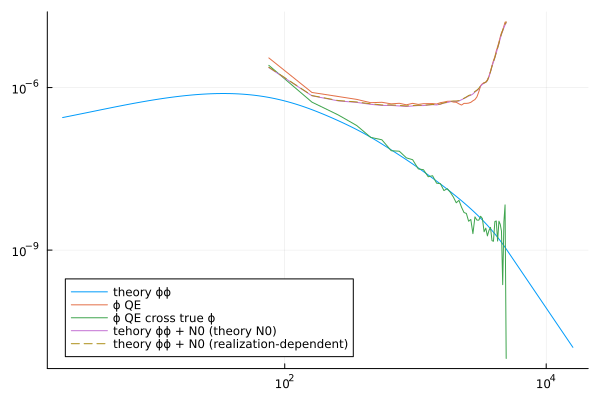

In [13]:
plot(ℓ⁴ * Cℓ.total.ϕϕ, xscale=:log10, yscale=:log10, label="theory ϕϕ")
plot!(Cℓ_ϕqe.ℓ,  max.(Cℓ_ϕqe.ℓ.^4 .*Cℓ_ϕqe.Cℓ, 1e-11), label="ϕ QE", legend=:bottomleft)
plot!(Cl_cross.ℓ,  max.(Cl_cross.ℓ.^4 .*Cl_cross.Cℓ, 1e-11), label="ϕ QE cross true ϕ")

plot!(ℓ⁴ * (Cℓ.total.ϕϕ + Cℓ_N0), label="tehory ϕϕ + N0 (theory N0)")
plot!(ℓ⁴ * (Cℓ.total.ϕϕ + CL_N0_RD), label="theory ϕϕ + N0 (realization-dependent)", ls=:dash)

In [15]:
# Monte Carlo covariance of C_L^{ϕϕ} estimates with and without RDN0 debiasing
Nsims_cov = 100
seed_offset_cov = 1000

function sample_covariance_matrix(samples::AbstractMatrix)
    centered = samples .- mean(samples, dims=1)
    centered' * centered / (size(samples, 1) - 1)
end

function cov2corr(cov::AbstractMatrix)
    D = sqrt.(diag(cov))
    cov ./ (D * D')
end

function qe_power_covariance_from_sims(; Nsims=Nsims_cov, seed_offset=seed_offset_cov)
    ℓbins = nothing
    cl_raw = Matrix{Float64}(undef, 0, 0)
    cl_rdn0sub = Matrix{Float64}(undef, 0, 0)

    @showprogress for sim_idx in 1:Nsims
        seed = seed_offset + sim_idx
        sim = load_sim(; seed, Cℓ, Cℓn, θpix, T, Nside, pol, beamFWHM, bandpass_mask=LowPass(lmax_ivf))

        ϕqe = quadratic_estimate(sim.ds, which, wiener_filtered=false, weights=:unlensed).ϕqe
        Cℓ_qe = get_Cℓ(ϕqe; ℓedges)
        Cℓ_rdn0 = cov_to_Cℓ(N0_bias(sim.ds, which; realization_spec=:data).N0; ℓedges)

        nbins = minimum(length.((Cℓ_qe.ℓ, Cℓ_rdn0.ℓ)))

        if sim_idx == 1
            ℓbins = Float64.(Cℓ_qe.ℓ[1:nbins])
            cl_raw = Matrix{Float64}(undef, Nsims, nbins)
            cl_rdn0sub = similar(cl_raw)
        else
            @assert Cℓ_qe.ℓ[1:nbins] ≈ ℓbins
            @assert Cℓ_rdn0.ℓ[1:nbins] ≈ ℓbins
        end

        cl_raw[sim_idx, :] = Float64.(Cℓ_qe.Cℓ[1:nbins])
        cl_rdn0sub[sim_idx, :] = Float64.(Cℓ_qe.Cℓ[1:nbins] .- Cℓ_rdn0.Cℓ[1:nbins])
    end

    cov_raw = sample_covariance_matrix(cl_raw)
    cov_rdn0sub = sample_covariance_matrix(cl_rdn0sub)

    (; ℓbins, cl_raw, cl_rdn0sub, cov_raw, cov_rdn0sub)
end



qe_power_covariance_from_sims (generic function with 1 method)

In [16]:
cov_res = qe_power_covariance_from_sims(Nsims=Nsims_cov)


Progress: 100%|█████████████████████████████████████████| Time: 0:02:58


(ℓbins = [75.5859784184188, 161.4816697488842, 257.08961557715776, 355.36867402589723, 454.5251933803815, 553.4419159538242, 652.8159299504382, 752.4372661461331, 851.6380381511643, 951.2924166060047  …  4049.3739175447404, 4149.269563616017, 4249.16265433738, 4349.120744273543, 4448.975833119803, 4548.496290293397, 4648.1816017529845, 4747.68133366465, 4845.955367017637, 4942.27394215414], cl_raw = [1.7565529343286448e-13 1.2913365271255128e-15 … 2.6547123943321643e-20 2.5982196319206974e-20; 3.5479038047136234e-13 1.3063675057518046e-15 … 2.6300419693556285e-20 2.786709032567987e-20; … ; 1.7110776406856475e-13 1.2525794934137946e-15 … 2.7519527261954225e-20 2.769108185248853e-20; 1.496581558111834e-13 1.3115724939531142e-15 … 2.9524537020525574e-20 2.6687499554985498e-20], cl_rdn0sub = [1.2371472298648208e-13 8.268730743679033e-16 … 6.491540532825331e-22 1.3478437235389524e-22; 3.017382511927485e-13 8.305929313785712e-16 … -4.078426004388223e-22 1.1634864244211205e-21; … ; 1.20520011

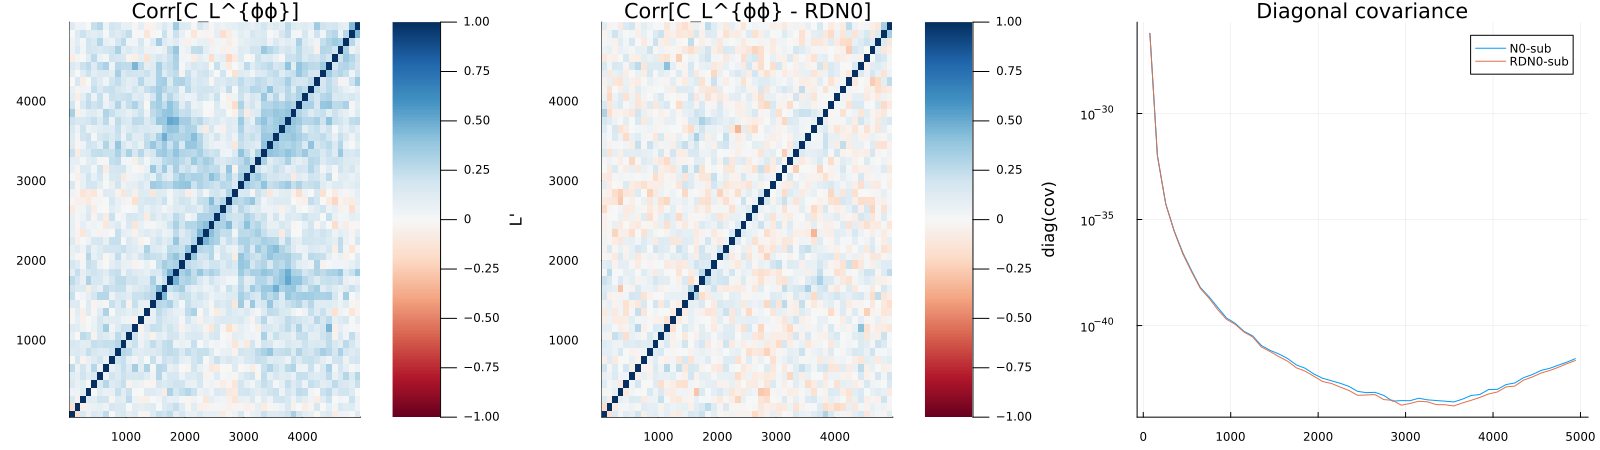

In [20]:
p1 = heatmap(cov_res.ℓbins, cov_res.ℓbins, cov2corr(cov_res.cov_raw),
    xlabel="L", ylabel="L'", title="Corr[C_L^{ϕϕ}]",  clims=(-1, 1), cmap=:RdBu)
p2 = heatmap(cov_res.ℓbins, cov_res.ℓbins, cov2corr(cov_res.cov_rdn0sub),
    xlabel="L", ylabel="L'", title="Corr[C_L^{ϕϕ} - RDN0]",  clims=(-1, 1), cmap=:RdBu)
p3 = plot(cov_res.ℓbins, diag(cov_res.cov_raw), yscale=:log10,
    xlabel="L", ylabel="diag(cov)", label="N0-sub", title="Diagonal covariance")
plot!(cov_res.ℓbins, diag(cov_res.cov_rdn0sub), label="RDN0-sub")

plot(p1, p2, p3, layout=(1, 3), size=(1600, 450))